# Assignment: week 1

In [149]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten

## Datan esikäsittely

Haetaan iris datasetti ja one-hot enkoodataan se ```pd.get_dummies()``` metodilla.

One-hot tekee kohdemuuttujasta binäärisen, arvoilla True/False.

In [151]:
df = pd.read_csv("../datasets/iris.data.txt", header=None)
df = pd.get_dummies(df)
df

,0,1,2,3,4_Iris-setosa,4_Iris-versicolor,4_Iris-virginica
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,False,True
146,6.3,2.5,5.0,1.9,False,False,True
147,6.5,3.0,5.2,2.0,False,False,True
148,6.2,3.4,5.4,2.3,False,False,True


Sekoitetaan datasetin indeksit.

Uudelleenjärjestetään datasetti käyttäen edellämainittuja indeksejä.

In [152]:
idx = df.index.to_list()
np.random.shuffle(idx)

df = df.loc[idx].reset_index(drop=True)
df

,0,1,2,3,4_Iris-setosa,4_Iris-versicolor,4_Iris-virginica
0,5.7,2.6,3.5,1.0,False,True,False
1,4.4,2.9,1.4,0.2,True,False,False
2,6.3,2.8,5.1,1.5,False,False,True
3,5.7,2.5,5.0,2.0,False,False,True
4,5.7,3.0,4.2,1.2,False,True,False
...,...,...,...,...,...,...,...
145,4.9,3.1,1.5,0.1,True,False,False
146,6.4,3.2,5.3,2.3,False,False,True
147,5.1,3.7,1.5,0.4,True,False,False
148,5.6,3.0,4.1,1.3,False,True,False


Erotetaan selittävät muuttujat kohdemuuttujasta.

- ```X``` = selittävät muuttujat
- ```y``` = kohdemuuttuja

In [153]:
X = df.iloc[:, :4].values
y = df.iloc[:, 4:].values

In [154]:
X

array([[5.7, 2.6, 3.5, 1. ],
       [4.4, 2.9, 1.4, 0.2],
       [6.3, 2.8, 5.1, 1.5],
       [5.7, 2.5, 5. , 2. ],
       [5.7, 3. , 4.2, 1.2],
       [6.2, 2.8, 4.8, 1.8],
       [4.6, 3.2, 1.4, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5.1, 3.5, 1.4, 0.2],
       [5.2, 4.1, 1.5, 0.1],
       [7.7, 3.8, 6.7, 2.2],
       [5. , 3.4, 1.5, 0.2],
       [6.3, 2.5, 4.9, 1.5],
       [5.5, 3.5, 1.3, 0.2],
       [6.1, 2.8, 4. , 1.3],
       [5.6, 2.5, 3.9, 1.1],
       [5.4, 3.4, 1.5, 0.4],
       [4.7, 3.2, 1.3, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [7.7, 2.8, 6.7, 2. ],
       [5.8, 2.7, 5.1, 1.9],
       [6.8, 2.8, 4.8, 1.4],
       [6.5, 3. , 5.8, 2.2],
       [4.9, 2.5, 4.5, 1.7],
       [6.9, 3.1, 5.1, 2.3],
       [6.2, 3.4, 5.4, 2.3],
       [5.6, 2.7, 4.2, 1.3],
       [7.1, 3. , 5.9, 2.1],
       [5.1, 3.8, 1.5, 0.3],
       [6.3, 2.5, 5. , 1.9],
       [6.5, 2.8, 4.6, 1.5],
       [6.2, 2.9, 4.3, 1.3],
       [5. , 2.3, 3.3, 1. ],
       [6. , 3.4, 4.5, 1.6],
       [6.7, 3

In [155]:
y

array([[False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [False, False,  True],
       [ True, False, False],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [False, False,  True],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [False, False,  True],
       [False, False,  True],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [Fa

## Mallinnus

Tuotetaan `Sequential` malli, joka ottaa `Input` syötekerroksen muotonaan 4-ulotteisen vektorin.

Vektori koostuu iris datasetin neljästä selittävästä muuttujasta:
- sepal length
- sepal width
- petal length
- petal width

Malli hyödyntää yhtä `Dense` piilokerrosta. Piilokerros on toteutettu 16 yksiköllä.

Ulostulo (Output) kerros sisältää 3 yksikköä, jotka vastaavat datasetin kohdemuuttujia.

Aktivaatiofunktioina toimii `ReLU` piilokerroksella ja `softmax` ulostulokerroksella.

In [156]:
model = Sequential([
    Input(shape=(4,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

Kootaan malli käyttäen `Adam` optimoijaa ja metriikkana tarkkuutta (accuracy). 

Adamin `learning_rate` parametrina päädyin `0.008`, joka tuotti vaaditun tarkkuuden mallille.

In [157]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.008),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Malli sovitetaan iris datasetillä käyttäen parametreja:
- `epochs` = 30 tuotti yleensä parhaat tulokset. Kun kokeilin pienempiä arvoja, malli tuntui jähmettyvän noin 80–90 %:n tarkkuuteen.
- `batch_size` = 32, joka on myös oletusarvo, näytti toimivan ihan hyvin. Kokeilin useita arvoja, mutta päädyin lopulta oletusarvoon, koska muut arvot eivät tuottaneet huomattavia positiivisia eroja.
- `validation_split` = 0.2 eli data on jaettu 80/20.  

In [ ]:
history = model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.4083 - loss: 1.9856 - val_accuracy: 0.6000 - val_loss: 1.3428
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6333 - loss: 1.1764 - val_accuracy: 0.6000 - val_loss: 0.9055
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4833 - loss: 0.9583 - val_accuracy: 0.4667 - val_loss: 0.9271
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6083 - loss: 0.8459 - val_accuracy: 0.6333 - val_loss: 0.7464
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6500 - loss: 0.6797 - val_accuracy: 0.6667 - val_loss: 0.6609
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6667 - loss: 0.6364 - val_accuracy: 0.6667 - val_loss: 0.6304
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6667 - loss: 0.6023 - val_accuracy: 0.7667 - val_loss: 0.5871
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6500 - loss: 0.5607 - val_accuracy: 0.6333 - val_loss: 0.5720

Plotataan mallin kehitys jokaisella epochilla.

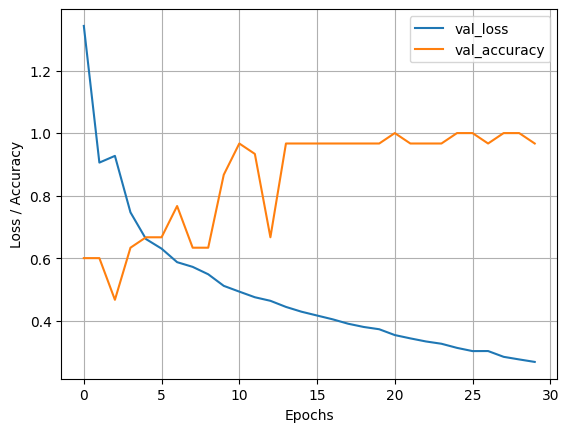

In [162]:
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Nähdään, että `val_loss` laskee räjähdysmäisesti noin 5 epochin ajan, minkä jälkeen lasku hidastuu ja jatkuu lähes lineaarisesti loppuajan.

In [160]:
test_loss, test_acc = model.evaluate(X, y)
print("Models performance")
print(f"Accuracy: {test_acc:.4f}\nLoss: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9667 - loss: 0.2714
Models performance
Accuracy: 0.9667
Loss: 0.2714


In [161]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395 (1.55 KB)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 264 (1.04 KB)